# ALS_LLRF_MTS test on LBL208
---

The following results were captured when looping back all 8 DACs to 8 ADCs through equal-length cables.


### Preparation from a PYNQ 3.0.1 image:

Run installation script: `./pynq_llrf/install.sh`.

In [1]:
%cd /home/xilinx/jupyter_notebooks/pynq_llrf

/home/xilinx/jupyter_notebooks/pynq_llrf


In [2]:
from mimo_mts import MimoMtsOverlay
import numpy as np

%load_ext autoreload
%autoreload 2

##  Configure SI570 to 156.1375 MHz

Due to EVG referece clock is 499.64 / 4 MHz, line rate is 2498.2 MHz.
GTY reference clock needs to be 2498.2 / 8 = 156.1375 MHz.

In [3]:
from mimo_mts.utils.config_si570 import SI570
with SI570() as si570:
    si570.set_freq(156.1375)

In [4]:
# reset PL to remove any cached .hwh file
# from pynq import PL
# PL.reset()

In [5]:
ol = MimoMtsOverlay(
    'als_llrf_mts.bit',
    board = 'LBL208',
    lmk_tcs='designs/CLK104/DIST_MTS_LMK04828.tcs',
    lmxadc_tcs='designs/CLK104/LMX2594_4000MHz.tcs',
    lmxdac_tcs='designs/CLK104/LMX2594_4000MHz.tcs')
ol.is_loaded()

True

In [7]:
ol.timestamp

'2025/4/28 2:28:5 +204561'

In [9]:
ol.evr.check_frequencies()

In [10]:
ol.evr

GT EVR GTY:      ['xilinx.com:module_ref:axil_evr:1.0']
Event count:     6689
GTY ref freq:    156.1371 MHz
GTY RX freq:     124.9107 MHz
Timestamp valid: True
Timestamp:       2147483648
GTY status:      0x7
RX aligned:      True

---

### Test deterministic latency incurred due to alignment
Every reboot should result in the same latency and offet \
Example: \
DAC Latency: 128, Offset: 0 \
ADC Latency:  96, Offset: 0

In [11]:
for i in range(4):
    print(f"DAC Tile {i} Latency: {ol.rfdc.mts_dac_config.Latency[i]:3d}, "
          f"Offset: {ol.rfdc.mts_dac_config.Offset[i]}\n"
          f"ADC Tile {i} Latency: {ol.rfdc.mts_adc_config.Latency[i]:3d}, "
          f"Offset: {ol.rfdc.mts_adc_config.Offset[i]}")

DAC Tile 0 Latency: 128, Offset: 8
ADC Tile 0 Latency:  96, Offset: 8
DAC Tile 1 Latency: 128, Offset: 8
ADC Tile 1 Latency:  96, Offset: 8
DAC Tile 2 Latency: 128, Offset: 8
ADC Tile 2 Latency:  96, Offset: 8
DAC Tile 3 Latency: 128, Offset: 8
ADC Tile 3 Latency:  96, Offset: 8


# Configure trigger

EVR, 1 Hz

In [13]:
ol.rf_control.register_map.trig_period = 250e6
ol.rf_control.register_map.trig_sel = 1  # EVR trigger
ol.rf_control.register_map.trig_delay = 0
ol.rf_control.register_map.trig_divide = 1
ol.rf_control.register_map.dac_enable = 1
ol.rf_control.register_map.pulse_length = 4096
ol.rf_control.register_map.amp_loop_setpoint = 0

There is a 3GHz band-pass filter between dac0 and adc0 loopback.

* Set DAC baseband waveform as DC
* Set DAC Mixer frequency to 3GHz for up conversion
* Set ADC Mixer frequency to 0Hz to check RF waveform

In [15]:
dac_i = np.ones(ol.dac_player.size//2, dtype=np.int16) * 32767
dac_q = np.zeros_like(dac_i)

In [16]:
ol.write_dac_iq_buf(dac_i, dac_q)

In [17]:
from mimo_mts.utils.plot import plot_complex_wfm

fs = ol.board.adc_sampling_rate
start = 1180 + 128 # start of the signal
print(f'RF loop back latency: {start/fs * 1e9} ns')

RF loop back latency: 327.0 ns


In [18]:
ol.set_dac_mixer_dco(-3000, nyquist=2)

In [19]:
ol.set_adc_mixer_dco(0, phase=0)

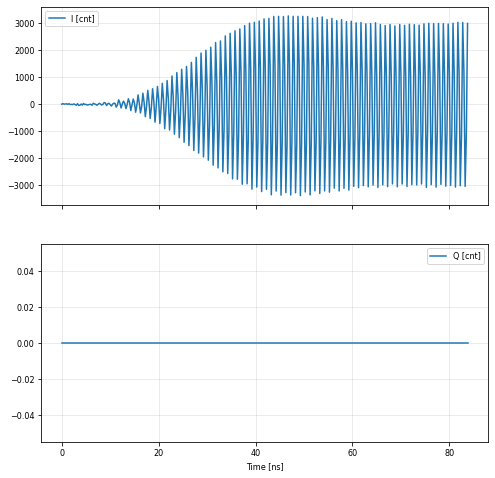

In [20]:
darray_i, darray_q = ol.capture_adc_iq_buf();
cdata = darray_i + 1j*darray_q
plot_complex_wfm(cdata[0, start-80:start+256], fs=fs)

Set ADC Mixer frequency to 3GHz, check I/Q waveform after mixing.

In [21]:
ol.set_adc_mixer_dco(3000, nyquist=2, phase=0)

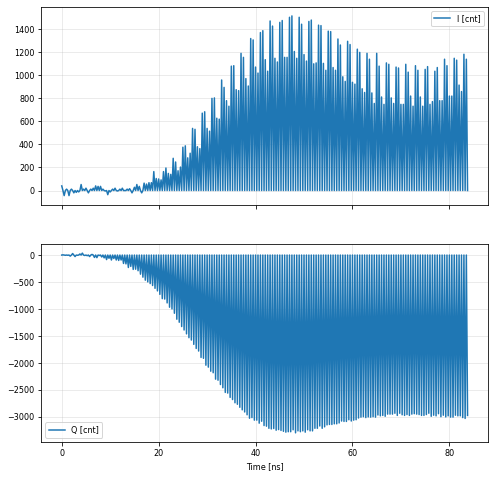

In [22]:
darray_i, darray_q = ol.capture_adc_iq_buf();
cdata = darray_i + 1j*darray_q
plot_complex_wfm(cdata[0, start-80:start+256], fs=fs)

Average ADC data by 8 samples, as the same to the LLRF DSP, equivalent to a low pass filter to get base band signal.

In [23]:
cdata_dsp = cdata.reshape(8, -1, 8).mean(axis=2)

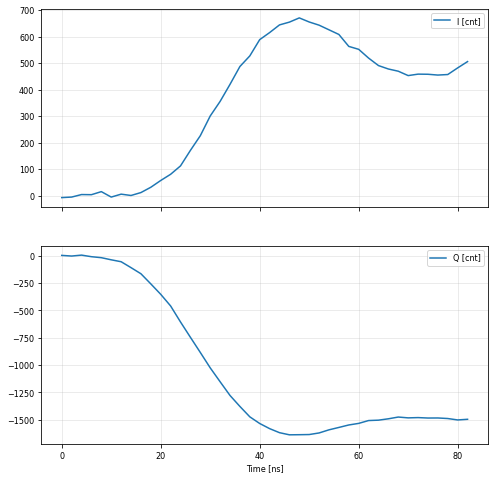

In [24]:
plot_complex_wfm(cdata_dsp[0, (start-80)//8:(start+256)//8], fs=fs/8)

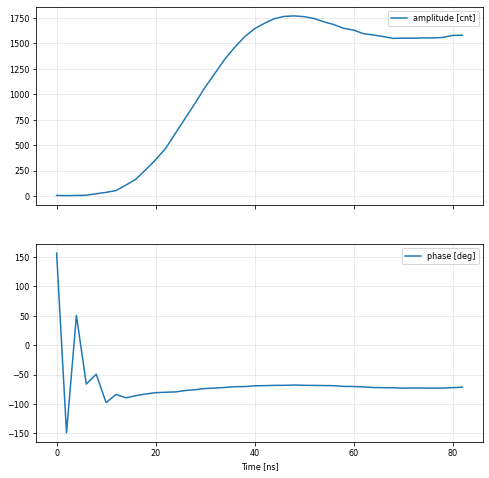

In [25]:
plot_complex_wfm(cdata_dsp[0, (start-80)//8:(start+256)//8], fs=fs/8, mode='ap')

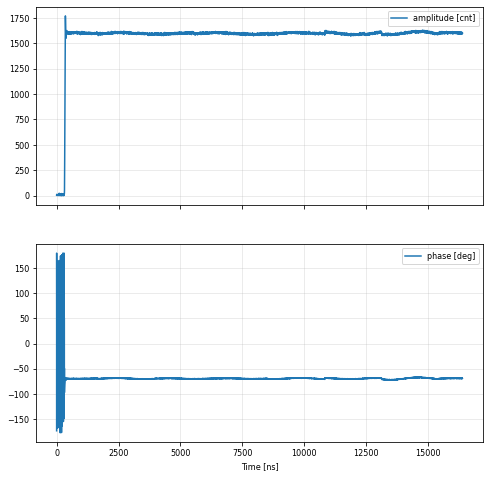

In [26]:
plot_complex_wfm(cdata_dsp[0], fs=fs/8, mode='ap')

# Disable dac buffer, use llrf amplitude setpoint for CW signal

In [27]:
ol.dac_player[:] = np.zeros(ol.dac_player.size, dtype=np.int16)

In [49]:
ol.rf_control.register_map.amp_loop_setpoint = 32767 / ol.rf_control.tx_gain / 2
ol.rf_control.register_map.phs_loop_setpoint = 0

In [61]:
def show_dsp_waveform(ch=0, mode='ap', start=0, end=-1):
    darray_i, darray_q = ol.capture_adc_iq_buf();
    cdata = darray_i + 1j*darray_q
    cdata_dsp = cdata.reshape(8, -1, 8).mean(axis=2)
    plot_complex_wfm(cdata_dsp[ch, start:end], fs=fs/8, mode=mode)
    return cdata_dsp

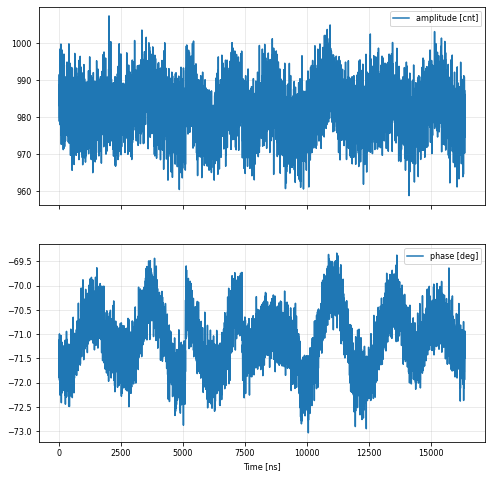

In [56]:
cdata_dsp = show_dsp_waveform(0)

Change RF amplitude by amp_loop_setpoint, and RF phase by phs_loop_setpoint

In [57]:
phs_measured = np.angle(cdata_dsp[0], deg=True).mean()
print(f'Measured RF phase: {phs_measured:.2f} deg')

Measured RF phase: -71.11 deg


In [58]:
ol.rf_control.register_map.amp_loop_setpoint = 32767 / ol.rf_control.tx_gain
ol.rf_control.register_map.phs_loop_setpoint = -phs_measured / 360 * (1<<18)

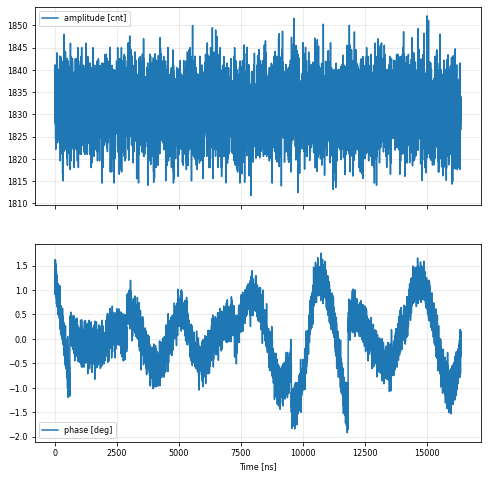

In [59]:
cdata_dsp = show_dsp_waveform(0)

# Check LLRF pulsing mode

In [60]:
ol.rf_control.register_map.dac_enable.pulse_enable=1

In [66]:
ol.rf_control.register_map.pulse_length=100

Expect 4 ns * 100 = 400 ns pulse length

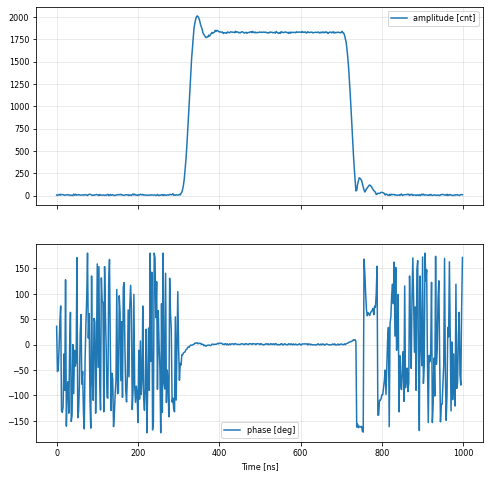

In [68]:
cdata_dsp = show_dsp_waveform(0, start=0, end=500)

# Close LLRF loop in CW mode

In [78]:
ol.rf_control.register_map.dac_enable.pulse_enable=0
ol.rf_control.register_map.amp_loop_setpoint = 30000
ol.rf_control.register_map.amp_loop_kp = 1
ol.rf_control.register_map.amp_loop_ki = 0
ol.rf_control.register_map.phs_loop_setpoint = 0

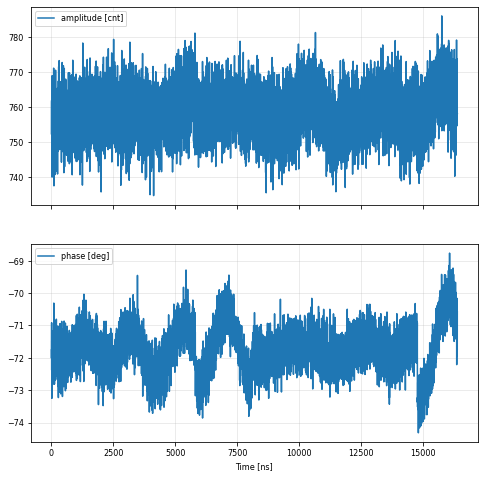

In [79]:
cdata_dsp = show_dsp_waveform(0)

In [82]:
ol.rf_control.register_map.amp_loop_reset = 1
ol.rf_control.register_map.amp_loop_reset = 0
ol.rf_control.register_map.amp_loop_enable = 0

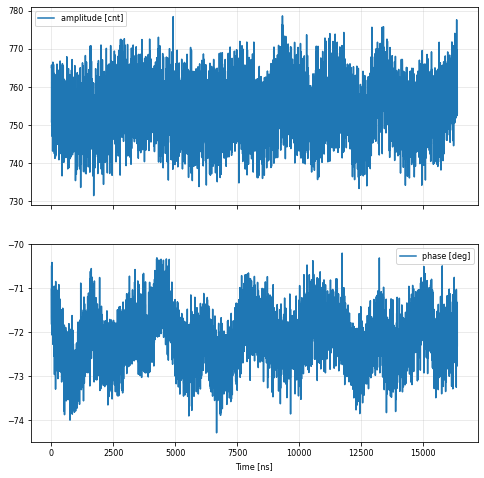

In [83]:
cdata_dsp = show_dsp_waveform(0)